In [ ]:
import requests
import pandas as pd

url = "https://api.binance.com/api/v3/klines"
params = {"symbol": "BTCUSDT" , "interval": "1h", "limit": 1000}
raw = requests.get(url, params=params).json()

df = pd.DataFrame([row[:6] for row in raw], columns=['Time','Open','High','Low','Close','Volume'])
df['Time'] = pd.to_datetime(df['Time'],unit='ms')
df['Close'] = df['Close'].astype(float)
df.head(-5)

,Time,Open,High,Low,Close,Volume
0,2026-03-22 09:00:00,68804.77000000,68901.65000000,68587.78000000,68826.20,383.82763000
1,2026-03-22 10:00:00,68826.21000000,68847.83000000,68584.27000000,68648.17,360.03346000
2,2026-03-22 11:00:00,68648.16000000,68691.03000000,68110.55000000,68217.95,784.43160000
3,2026-03-22 12:00:00,68217.94000000,68763.18000000,68199.04000000,68654.83,484.24300000
4,2026-03-22 13:00:00,68654.83000000,68957.24000000,68548.32000000,68700.02,548.07349000
...,...,...,...,...,...,...
990,2026-05-02 15:00:00,78423.98000000,78487.68000000,78365.96000000,78487.67,126.14054000
991,2026-05-02 16:00:00,78487.67000000,78596.61000000,78430.07000000,78455.02,194.42514000
992,2026-05-02 17:00:00,78455.02000000,78485.53000000,78368.24000000,78398.02,213.39843000
993,2026-05-02 18:00:00,78398.03000000,78493.31000000,78310.54000000,78466.62,118.15969000


In [2]:
import numpy as np
df['ma10'] = df['Close'].rolling(window=10).mean()
df['ma30'] = df['Close'].rolling(window=30).mean()
df['signal'] = np.where( df['ma10'] < df['ma30'], 1, 0 )
arr=df['signal']
df['signal'] = np.where( df['ma30'] < df['ma10'] , -1 , arr)
df['signal'].value_counts()

signal
-1    547
 1    424
 0     29
Name: count, dtype: int64

In [3]:
df['pct_return'] = df['Close'].pct_change()*df['signal'].shift(1)
df['cumulative'] = (1+df['pct_return']).cumprod()
df['buynhold'] = df['Close']/df['Close'][0]
df['cumulative'].value_counts()

cumulative
1.000000    29
1.018405     1
1.012160     1
1.004649     1
1.004775     1
            ..
1.175900     1
1.171877     1
1.170192     1
1.172361     1
1.173161     1
Name: count, Length: 971, dtype: int64

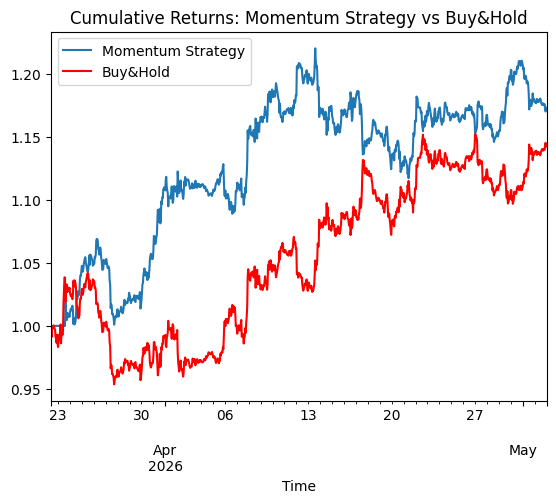

In [10]:
import matplotlib.pyplot as plt
ax = df.plot(x='Time',y='cumulative', kind ='line', title= 'Cumulative Returns: Momentum Strategy vs Buy&Hold', label = 'Momentum Strategy')

df.plot(x='Time', y='buynhold', kind = 'line', color = 'red', label = 'Buy&Hold', ax=ax)
plt.xlabel('Time')
plt.savefig('results.png')
plt.show()